In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving cdnnba_2020.tar.xz to cdnnba_2020.tar.xz
Saving cdnnba_2021.tar.xz to cdnnba_2021.tar.xz
Saving cdnnba_2022.tar.xz to cdnnba_2022.tar.xz
Saving cdnnba_2023.tar.xz to cdnnba_2023.tar.xz
Saving cdnnba_2024.tar.xz to cdnnba_2024.tar.xz
Saving cdnnba_2025.tar.xz to cdnnba_2025.tar.xz
User uploaded file "cdnnba_2020.tar.xz" with length 15548680 bytes
User uploaded file "cdnnba_2021.tar.xz" with length 17660924 bytes
User uploaded file "cdnnba_2022.tar.xz" with length 18705272 bytes
User uploaded file "cdnnba_2023.tar.xz" with length 18598380 bytes
User uploaded file "cdnnba_2024.tar.xz" with length 18886652 bytes
User uploaded file "cdnnba_2025.tar.xz" with length 16283472 bytes


In [ ]:
import re
import tarfile
import pandas as pd
import numpy as np

def clock_to_t(clock, period):
    match = re.search(r'PT(\d+)M([\d.]+)S', str(clock))
    if not match:
        return None
    mins = int(match.group(1))
    secs = float(match.group(2))
    mins_remaining = mins + secs/60
    mins_completed = (period - 1) * 12 + (12 - mins_remaining)
    return mins_completed / 48

In [ ]:
files = {
    2020: 'cdnnba_2020.tar.xz',
    2021: 'cdnnba_2021.tar.xz',
    2022: 'cdnnba_2022.tar.xz',
    2023: 'cdnnba_2023.tar.xz',
    2024: 'cdnnba_2024.tar.xz',
    2025: 'cdnnba_2025.tar.xz'
}

dfs = []
for season, filename in files.items():
    with tarfile.open(filename, 'r:xz') as tar:
        tar.extractall('.')
    df_season = pd.read_csv(f'cdnnba_{season}.csv')
    df_season['season'] = season
    dfs.append(df_season)
    print(f'Loaded {season}: {len(df_season)} rows')

df_all = pd.concat(dfs, ignore_index=True)
print(f'\nTotal rows: {len(df_all)}')

/tmp/ipykernel_20623/3825032094.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('.')


Loaded 2020: 605198 rows


/tmp/ipykernel_20623/3825032094.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('.')


Loaded 2021: 691875 rows


/tmp/ipykernel_20623/3825032094.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('.')
/tmp/ipykernel_20623/3825032094.py:14: DtypeWarning: Columns (56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  df_season = pd.read_csv(f'cdnnba_{season}.csv')


...

Loaded 2023: 674937 rows


/tmp/ipykernel_20623/3825032094.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('.')


Loaded 2024: 686008 rows


/tmp/ipykernel_20623/3825032094.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('.')


Loaded 2025: 598767 rows

Total rows: 3936517


In [ ]:
df_all['t'] = df_all.apply(lambda row: clock_to_t(row['clock'], row['period']), axis=1)
df_all['lead'] = pd.to_numeric(df_all['scoreHome'], errors='coerce') - pd.to_numeric(df_all['scoreAway'], errors='coerce')

df_scoring = df_all.dropna(subset=['lead'])
df_scoring = df_scoring.sort_values(['gameId', 'orderNumber'])
df_scoring = df_scoring[df_scoring['lead'] != df_scoring.groupby('gameId')['lead'].shift(1)]

print(f'Scoring plays: {len(df_scoring)}')

Scoring plays: 837390


In [ ]:
df_scoring = df_scoring.copy()
df_scoring['lead_change'] = df_scoring.groupby('gameId')['lead'].diff()
df_scoring = df_scoring.dropna(subset=['lead_change'])

bins = [i * 3/48 for i in range(17)]
labels = [i * 3 for i in range(16)]
df_scoring['t_bin'] = pd.cut(df_scoring['t'], bins=bins, labels=labels)

sigma_by_bin = df_scoring.groupby('t_bin')['lead_change'].std()
print(sigma_by_bin)

t_bin
0     2.180349
3     2.126354
6     2.094132
9     2.047090
12    2.093636
15    2.073536
18    2.034615
21    1.986797
24    2.113979
27    2.067768
30    2.025327
33    1.982229
36    2.072845
39    2.060255
42    2.014757
45    1.890197
Name: lead_change, dtype: float64


/tmp/ipykernel_20623/936674505.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sigma_by_bin = df_scoring.groupby('t_bin')['lead_change'].std()


In [ ]:
def negative_log_likelihood_sigma(sigma, mu, data):
    if sigma <= 0:
        return 1e10
    probs = win_probability(data['lead'].values, data['t'].values, mu, sigma)
    likelihood = np.where(data['home_win'].values == 1, probs, 1 - probs)
    likelihood = np.clip(likelihood, 1e-10, 1 - 1e-10)
    return -np.sum(np.log(likelihood))


In [ ]:
final_scores = df_scoring.groupby('gameId')['lead'].last()
home_win_map = (final_scores > 0).astype(int)
df_scoring['home_win'] = df_scoring['gameId'].map(home_win_map)
print(df_scoring[['gameId', 'lead', 'home_win']].head(20))

      gameId  lead  home_win
4   22000001    -1         1
5   22000001    -2         1
6   22000001     0         1
7   22000001    -2         1
8   22000001     1         1
11  22000001     3         1
14  22000001     6         1
19  22000001     4         1
28  22000001     6         1
30  22000001     7         1
32  22000001     6         1
33  22000001     5         1
39  22000001     8         1
46  22000001    10         1
53  22000001    12         1
59  22000001    11         1
60  22000001    14         1
73  22000001    12         1
74  22000001    15         1
75  22000001    13         1


In [ ]:
from scipy.stats import norm

def win_probability(lead, t, mu, sigma):
    numerator = lead + (1 - t) * mu
    denominator = np.sqrt((1 - t) * sigma**2)
    return norm.cdf(numerator / denominator)

In [ ]:
from scipy.optimize import minimize_scalar

mu_fixed = 4.94
segments = [(i*6/48, (i+1)*6/48) for i in range(8)]
sigma_by_segment = []

for t_start, t_end in segments:
    segment_data = df_scoring[(df_scoring['t'] >= t_start) & (df_scoring['t'] < t_end)]

    result = minimize_scalar(
        negative_log_likelihood_sigma,
        bounds=(1, 50),
        method='bounded',
        args=(mu_fixed, segment_data)
    )

    sigma_by_segment.append((t_start, t_end, result.x))
    print(f't={t_start:.3f} to {t_end:.3f}: sigma = {result.x:.2f}')

t=0.000 to 0.125: sigma = 28.63
t=0.125 to 0.250: sigma = 22.45
t=0.250 to 0.375: sigma = 20.49
t=0.375 to 0.500: sigma = 19.61
t=0.500 to 0.625: sigma = 19.42
t=0.625 to 0.750: sigma = 18.96
t=0.750 to 0.875: sigma = 18.65
t=0.875 to 1.000: sigma = 20.47


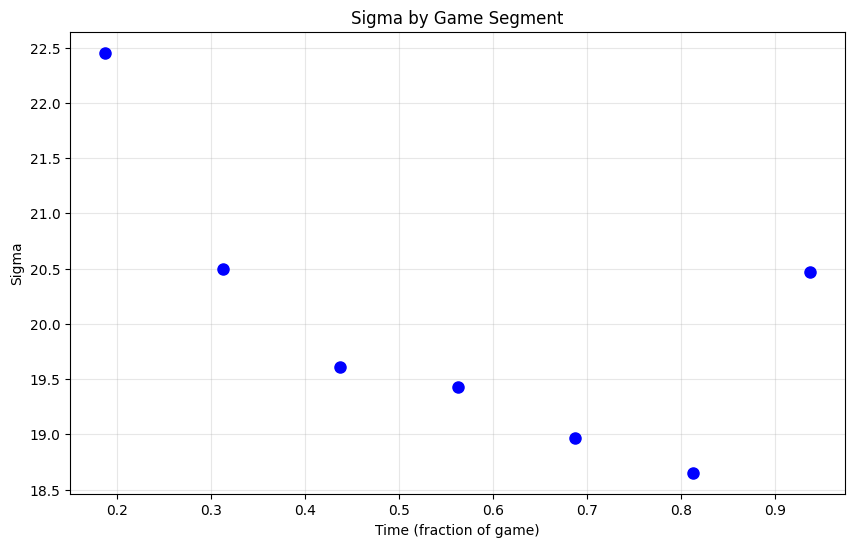

Points for regression (excluding first):
t=0.1875, sigma=22.45
t=0.3125, sigma=20.49
t=0.4375, sigma=19.61
t=0.5625, sigma=19.42
t=0.6875, sigma=18.96
t=0.8125, sigma=18.65
t=0.9375, sigma=20.47


In [ ]:
import matplotlib.pyplot as plt

t_mids = [0.0625, 0.1875, 0.3125, 0.4375, 0.5625, 0.6875, 0.8125, 0.9375]
sigmas = [s[2] for s in sigma_by_segment]

# Plot excluding first point
plt.figure(figsize=(10, 6))
plt.plot(t_mids[1:], sigmas[1:], 'bo', markersize=8)
plt.xlabel('Time (fraction of game)')
plt.ylabel('Sigma')
plt.title('Sigma by Game Segment')
plt.grid(True, alpha=0.3)
plt.show()

print("Points for regression (excluding first):")
for t, s in zip(t_mids[1:], sigmas[1:]):
    print(f"t={t:.4f}, sigma={s:.2f}")

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("christophertreasure/nba-odds-data")

print("Path to dataset files:", path)

100%|██████████| 551k/551k [00:00<00:00, 63.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/christophertreasure/nba-odds-data/versions/3


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize

def win_probability(lead, t, mu, sigma):
    numerator = lead + (1 - t) * mu
    denominator = np.sqrt((1 - t) * sigma**2)
    return norm.cdf(numerator / denominator)

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("christophertreasure/nba-odds-data")
files = os.listdir(path)
print("Files:", files)

Using Colab cache for faster access to the 'nba-odds-data' dataset.
Files: ['oddsData.csv']


In [ ]:
df_odds = pd.read_csv(path + '/oddsData.csv')  #odds replace FILENAME
print(df_odds.shape)
print(df_odds.columns.tolist())
print(df_odds[['team', 'home/visitor', 'opponent', 'score', 'opponentScore', 'spread']].head(20))

(37104, 12)
['date', 'season', 'team', 'home/visitor', 'opponent', 'score', 'opponentScore', 'moneyLine', 'opponentMoneyLine', 'total', 'spread', 'secondHalfTotal']
            team home/visitor      opponent  score  opponentScore  spread
0           Utah            @  Golden State    117             96     1.0
1      LA Lakers           vs       Houston     93             95     5.0
2        Houston            @     LA Lakers     95             93    -5.0
3    San Antonio           vs      Portland    106             97   -13.0
4       Portland            @   San Antonio     97            106    13.0
5   Golden State           vs          Utah     96            117    -1.0
6     New Jersey           vs       Chicago    112            103    -1.5
7         Dallas            @     Cleveland     92             74    -2.5
8      Cleveland           vs        Dallas     74             92     2.5
9        Seattle            @        Denver    103            120    11.5
10    Washington     

In [ ]:
print(sorted(df_odds['team'].unique()))

['Atlanta', 'Boston', 'Brooklyn', 'Charlotte', 'Chicago', 'Cleveland', 'Dallas', 'Denver', 'Detroit', 'Golden State', 'Houston', 'Indiana', 'LA Clippers', 'LA Lakers', 'Memphis', 'Miami', 'Milwaukee', 'Minnesota', 'New Jersey', 'New Orleans', 'New York', 'Oklahoma City', 'Orlando', 'Philadelphia', 'Phoenix', 'Portland', 'Sacramento', 'San Antonio', 'Seattle', 'Toronto', 'Utah', 'Washington']


In [ ]:
import kagglehub
path2 = kagglehub.dataset_download("joybiswas389/nba-matches-results-1949-2024")
df_nba = pd.read_csv(path2 + '/nba.csv')
print(sorted(df_nba['team1'].unique()))

100%|██████████| 1.68M/1.68M [00:00<00:00, 104MB/s]

Extracting files...


['76ers', 'Adecco ASVEL', 'Alba Berlin', 'Armani Jeans Milano', 'BC', 'Barry', 'Basket', 'Blackhawks', 'Bobcats', 'Bombers', 'Braves', 'Buckler Bologna', 'Bucks', 'Bullets', 'Bulls', 'CSKA', 'Canada', 'Capitols', 'Cavaliers', 'Celtics', 'China', 'Chuck', 'Clippers', 'Clutch City', 'Croatia', 'Deron', 'Durant', 'EA7 Emporio Armani Milano', 'East', 'Efes Pilsen', 'FC Barcelona Lassa', 'FC Barcelona Regal', 'Fenerbahce Ulker', 'Flamengo', 'Giannis', 'Grizzlies', 'Hawks', 'Heat', 'Home', 'Hornets', 'Isiah', 'Jason', 'Jazz', 'Jazz Blue', 'Jazz White', 'Kings', 'Knicks', 'Lakers', 'LeBron', 'Lottomatica Roma', 'MMT Estudiantes', 'Maccabi Elite', 'Magic', 'Mavericks', 'NBA D-League Select', 'Nationals', 'Nets', 'Nuggets', 'Olimpia Milano', 'Olympians', 'Pacers', 'Packers', 'Pallacanestro Varese', 'Pau', 'Pelicans', 'Perth Wildcats', 'Pistons', 'Raptors', 'Real Madrid', 'Redskins', 'Regal FC', 'Rockets', 'Rookies', 'Royals', 'Sophomores', 'Spain', 'Spurs', 'Stags', 'Stephen', 'Suns', 'SuperSon

In [ ]:
valid_teams = ['76ers', 'Bobcats', 'Bucks', 'Bulls', 'Cavaliers', 'Celtics',
               'Clippers', 'Grizzlies', 'Hawks', 'Heat', 'Hornets', 'Jazz',
               'Kings', 'Knicks', 'Lakers', 'Magic', 'Mavericks', 'Nets',
               'Nuggets', 'Pacers', 'Pelicans', 'Pistons', 'Raptors', 'Rockets',
               'Spurs', 'Suns', 'SuperSonics', 'Thunder', 'Timberwolves',
               'Trail Blazers', 'Warriors', 'Wizards']

df_nba_filtered = df_nba[df_nba['team1'].isin(valid_teams) & df_nba['team2'].isin(valid_teams)]
print(f'Filtered rows: {len(df_nba_filtered)}')
print(df_nba_filtered['team1'].unique())

Filtered rows: 65285
['Warriors' 'Hawks' 'Pistons' 'Celtics' 'Knicks' 'Nuggets' 'Lakers'
 '76ers' 'Bulls' 'Rockets' 'SuperSonics' 'Bucks' 'Suns' 'Trail Blazers'
 'Cavaliers' 'Kings' 'Jazz' 'Pacers' 'Spurs' 'Nets' 'Clippers' 'Mavericks'
 'Hornets' 'Heat' 'Magic' 'Timberwolves' 'Raptors' 'Grizzlies' 'Wizards'
 'Bobcats' 'Thunder' 'Pelicans']


In [ ]:
# Filter to home games only
df_home = df_odds[df_odds['home/visitor'] == 'vs'].copy()

# Apply team name mapping
df_home['team_short'] = df_home['team'].map(team_mapping)
df_home['opponent_short'] = df_home['opponent'].map(team_mapping)

# Flip spread so positive = home team favored
df_home['mu'] = -df_home['spread']

print(df_home[['team_short', 'opponent_short', 'score', 'opponentScore', 'mu']].head(10))
print(f'\nRows: {len(df_home)}')

   team_short opponent_short  score  opponentScore    mu
1      Lakers        Rockets     93             95  -5.0
3       Spurs  Trail Blazers    106             97  13.0
5    Warriors           Jazz     96            117   1.0
6        Nets          Bulls    112            103   1.5
8   Cavaliers      Mavericks     74             92  -2.5
12      Magic          Bucks    102             83   6.5
16    Raptors          76ers    106             97   6.5
17   Pelicans          Kings    104             90   9.5
18  Grizzlies          Spurs    101            104  -6.5
19    Nuggets    SuperSonics    120            103  11.5

Rows: 18649


In [ ]:
team_mapping = {
    'Atlanta': 'Hawks',
    'Boston': 'Celtics',
    'Brooklyn': 'Nets',
    'Charlotte': 'Bobcats',
    'Chicago': 'Bulls',
    'Cleveland': 'Cavaliers',
    'Dallas': 'Mavericks',
    'Denver': 'Nuggets',
    'Detroit': 'Pistons',
    'Golden State': 'Warriors',
    'Houston': 'Rockets',
    'Indiana': 'Pacers',
    'LA Clippers': 'Clippers',
    'LA Lakers': 'Lakers',
    'Memphis': 'Grizzlies',
    'Miami': 'Heat',
    'Milwaukee': 'Bucks',
    'Minnesota': 'Timberwolves',
    'New Jersey': 'Nets',
    'New Orleans': 'Pelicans',
    'New York': 'Knicks',
    'Oklahoma City': 'Thunder',
    'Orlando': 'Magic',
    'Philadelphia': '76ers',
    'Phoenix': 'Suns',
    'Portland': 'Trail Blazers',
    'Sacramento': 'Kings',
    'San Antonio': 'Spurs',
    'Seattle': 'SuperSonics',
    'Toronto': 'Raptors',
    'Utah': 'Jazz',
    'Washington': 'Wizards'
}

In [ ]:
# Filter to home games only
df_home = df_odds[df_odds['home/visitor'] == 'vs'].copy()

# Apply team name mapping
df_home['team_short'] = df_home['team'].map(team_mapping)
df_home['opponent_short'] = df_home['opponent'].map(team_mapping)

# Flip spread so positive = home team favored
df_home['mu'] = -df_home['spread']

print(df_home[['team_short', 'opponent_short', 'score', 'opponentScore', 'mu']].head(10))
print(f'\nRows: {len(df_home)}')

   team_short opponent_short  score  opponentScore    mu
1      Lakers        Rockets     93             95  -5.0
3       Spurs  Trail Blazers    106             97  13.0
5    Warriors           Jazz     96            117   1.0
6        Nets          Bulls    112            103   1.5
8   Cavaliers      Mavericks     74             92  -2.5
12      Magic          Bucks    102             83   6.5
16    Raptors          76ers    106             97   6.5
17   Pelicans          Kings    104             90   9.5
18  Grizzlies          Spurs    101            104  -6.5
19    Nuggets    SuperSonics    120            103  11.5

Rows: 18649


In [ ]:
df_merged = df_home.merge(
    df_nba_filtered,
    left_on=['team_short', 'opponent_short', 'score', 'opponentScore'],
    right_on=['team1', 'team2', 'team1_score', 'team2_score'],
    how='inner'
)

print(f'Merged rows: {len(df_merged)}')
print(df_merged.head(5))

Merged rows: 18078
         date  season          team home/visitor  opponent  score  \
0  2007-10-30    2008     LA Lakers           vs   Houston     93   
1  2007-10-30    2008   San Antonio           vs  Portland    106   
2  2007-10-30    2008  Golden State           vs      Utah     96   
3  2007-10-31    2008    New Jersey           vs   Chicago    112   
4  2007-10-31    2008     Cleveland           vs    Dallas     74   

   opponentScore  moneyLine  opponentMoneyLine  total  ...  period_Q5_team2  \
0             95      190.0             -230.0  199.0  ...                0   
1             97    -1400.0              900.0  189.5  ...                0   
2            117     -120.0              100.0  212.0  ...                0   
3            103     -125.0              105.0  186.0  ...                7   
4             92      120.0             -140.0  184.0  ...                0   

   period_Q6_team1 period_Q6_team2 period_Q7_team1  period_Q7_team2  \
0                0  

In [ ]:
print(df_home[df_home['team_short'].isna()]['team'].unique())
print(df_home[df_home['opponent_short'].isna()]['opponent'].unique())

[]
[]


In [ ]:
print(f'Home games in odds dataset: {len(df_home)}')
print(f'Games in filtered NBA dataset: {len(df_nba_filtered)}')

Home games in odds dataset: 18649
Games in filtered NBA dataset: 65285


In [ ]:
est_data = []

for idx, row in df_merged.iterrows():
    home_Q1 = row['period_Q1_team1']
    away_Q1 = row['period_Q1_team2']
    home_Q2 = home_Q1 + row['period_Q2_team1']
    away_Q2 = away_Q1 + row['period_Q2_team2']
    home_Q3 = home_Q2 + row['period_Q3_team1']
    away_Q3 = away_Q2 + row['period_Q3_team2']

    home_win = 1 - row['verdict']
    mu = row['mu']

    for lead, t in [(home_Q1 - away_Q1, 0.25),
                    (home_Q2 - away_Q2, 0.50),
                    (home_Q3 - away_Q3, 0.75)]:
        est_data.append({
            'lead': lead,
            't': t,
            'mu': mu,
            'home_win': home_win
        })

est_df = pd.DataFrame(est_data)
print(f'Total observations: {len(est_df)}')
print(est_df.head(9))

Total observations: 54234
   lead     t    mu  home_win
0     9  0.25  -5.0         0
1     0  0.50  -5.0         0
2    -8  0.75  -5.0         0
3     3  0.25  13.0         1
4    10  0.50  13.0         1
5     4  0.75  13.0         1
6     2  0.25   1.0         0
7   -11  0.50   1.0         0
8   -14  0.75   1.0         0


In [ ]:
def negative_log_likelihood_sigma_only(sigma, data):
    if sigma <= 0:
        return 1e10

    probs = win_probability(
        data['lead'].values,
        data['t'].values,
        data['mu'].values,  # per-game mu from spread
        sigma
    )

    likelihood = np.where(data['home_win'].values == 1, probs, 1 - probs)
    likelihood = np.clip(likelihood, 1e-10, 1 - 1e-10)
    return -np.sum(np.log(likelihood))

from scipy.optimize import minimize_scalar

result = minimize_scalar(
    negative_log_likelihood_sigma_only,
    bounds=(1, 50),
    method='bounded',
    args=(est_df,)
)

sigma_hat = result.x
print(f'Sigma with variable mu: {sigma_hat:.2f}')
print(f'Optimization successful: {result.success}')

Sigma with variable mu: 16.88
Optimization successful: True


In [ ]:
print(df_merged['date'].head(10))

0    2007-10-30
1    2007-10-30
2    2007-10-30
3    2007-10-31
4    2007-10-31
5    2007-10-31
6    2007-10-31
7    2007-10-31
8    2007-10-31
9    2007-10-31
Name: date, dtype: object


In [ ]:
df_merged['date'] = pd.to_datetime(df_merged['date'])

df_train = df_merged[df_merged['date'].dt.year != 2022]
df_test = df_merged[df_merged['date'].dt.year == 2022]

print(f'Training games: {len(df_train)}')
print(f'Test games: {len(df_test)}')

Training games: 16869
Test games: 1209


In [ ]:
# Build training estimation dataset
est_train = []

for idx, row in df_train.iterrows():
    home_Q1 = row['period_Q1_team1']
    away_Q1 = row['period_Q1_team2']
    home_Q2 = home_Q1 + row['period_Q2_team1']
    away_Q2 = away_Q1 + row['period_Q2_team2']
    home_Q3 = home_Q2 + row['period_Q3_team1']
    away_Q3 = away_Q2 + row['period_Q3_team2']

    home_win = 1 - row['verdict']
    mu = row['mu']

    for lead, t in [(home_Q1 - away_Q1, 0.25),
                    (home_Q2 - away_Q2, 0.50),
                    (home_Q3 - away_Q3, 0.75)]:
        est_train.append({
            'lead': lead,
            't': t,
            'mu': mu,
            'home_win': home_win
        })

est_train_df = pd.DataFrame(est_train)

# Refit sigma on training data only
result_train = minimize_scalar(
    negative_log_likelihood_sigma_only,
    bounds=(1, 50),
    method='bounded',
    args=(est_train_df,)
)

sigma_new = result_train.x
print(f'Sigma (trained without 2022): {sigma_new:.2f}')

Sigma (trained without 2022): 16.74


In [ ]:
# Build test estimation dataset at Q3 only
test_data = []

for idx, row in df_test.iterrows():
    home_Q1 = row['period_Q1_team1']
    away_Q1 = row['period_Q1_team2']
    home_Q2 = home_Q1 + row['period_Q2_team1']
    away_Q2 = away_Q1 + row['period_Q2_team2']
    home_Q3 = home_Q2 + row['period_Q3_team1']
    away_Q3 = away_Q2 + row['period_Q3_team2']

    test_data.append({
        'lead': home_Q3 - away_Q3,
        't': 0.75,
        'mu': row['mu'],
        'home_win': 1 - row['verdict']
    })

test_df = pd.DataFrame(test_data)

# Model 1: fixed mu = 4.94, sigma = 16.90 (Stern style)
probs_fixed = win_probability(test_df['lead'].values, test_df['t'].values, 4.94, 16.90)

# Model 2: variable mu from spread, sigma = 16.74
probs_variable = win_probability(test_df['lead'].values, test_df['t'].values, test_df['mu'].values, sigma_new)

# Brier scores
brier_fixed = np.mean((probs_fixed - test_df['home_win'].values)**2)
brier_variable = np.mean((probs_variable - test_df['home_win'].values)**2)

print(f'Brier score - Fixed mu: {brier_fixed:.4f}')
print(f'Brier score - Variable mu: {brier_variable:.4f}')
print(f'Improvement: {((brier_fixed - brier_variable)/brier_fixed)*100:.2f}%')

Brier score - Fixed mu: 0.1366
Brier score - Variable mu: 0.1333
Improvement: 2.42%


In [ ]:
def variable_sigma(t):
    if t < 0.125:
        return 28.63
    elif t < 0.250:
        return 22.45
    elif t < 0.375:
        return 20.49
    elif t < 0.500:
        return 19.61
    elif t < 0.625:
        return 19.42
    elif t < 0.750:
        return 18.96
    elif t < 0.875:
        return 18.65
    else:
        return 20.47

# Now calculate Brier scores on the 2022 test set
# Model 1: constant sigma
probs_constant = win_probability(
    test_df['lead'].values,
    test_df['t'].values,
    test_df['mu'].values,
    16.74
)

# Model 2: variable sigma
probs_variable_sigma = [win_probability(lead, t, mu, variable_sigma(t))
                        for lead, t, mu in zip(test_df['lead'].values,
                                               test_df['t'].values,
                                               test_df['mu'].values)]
probs_variable_sigma = np.array(probs_variable_sigma)

brier_constant = np.mean((probs_constant - test_df['home_win'].values)**2)
brier_variable_s = np.mean((probs_variable_sigma - test_df['home_win'].values)**2)

print(f'Brier score - constant sigma: {brier_constant:.4f}')
print(f'Brier score - variable sigma: {brier_variable_s:.4f}')
print(f'Difference: {((brier_constant - brier_variable_s)/brier_constant)*100:.2f}%')

Brier score - constant sigma: 0.1333
Brier score - variable sigma: 0.1326
Difference: 0.51%
